In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.linalg import null_space

from quaternion_ds.src.quat_class import quat_class
from quaternion_ds.src.util import plot_tools, load_tools, process_tools, quat_tools
from quaternion_ds.src.util.quat_tools import riem_log, parallel_transport

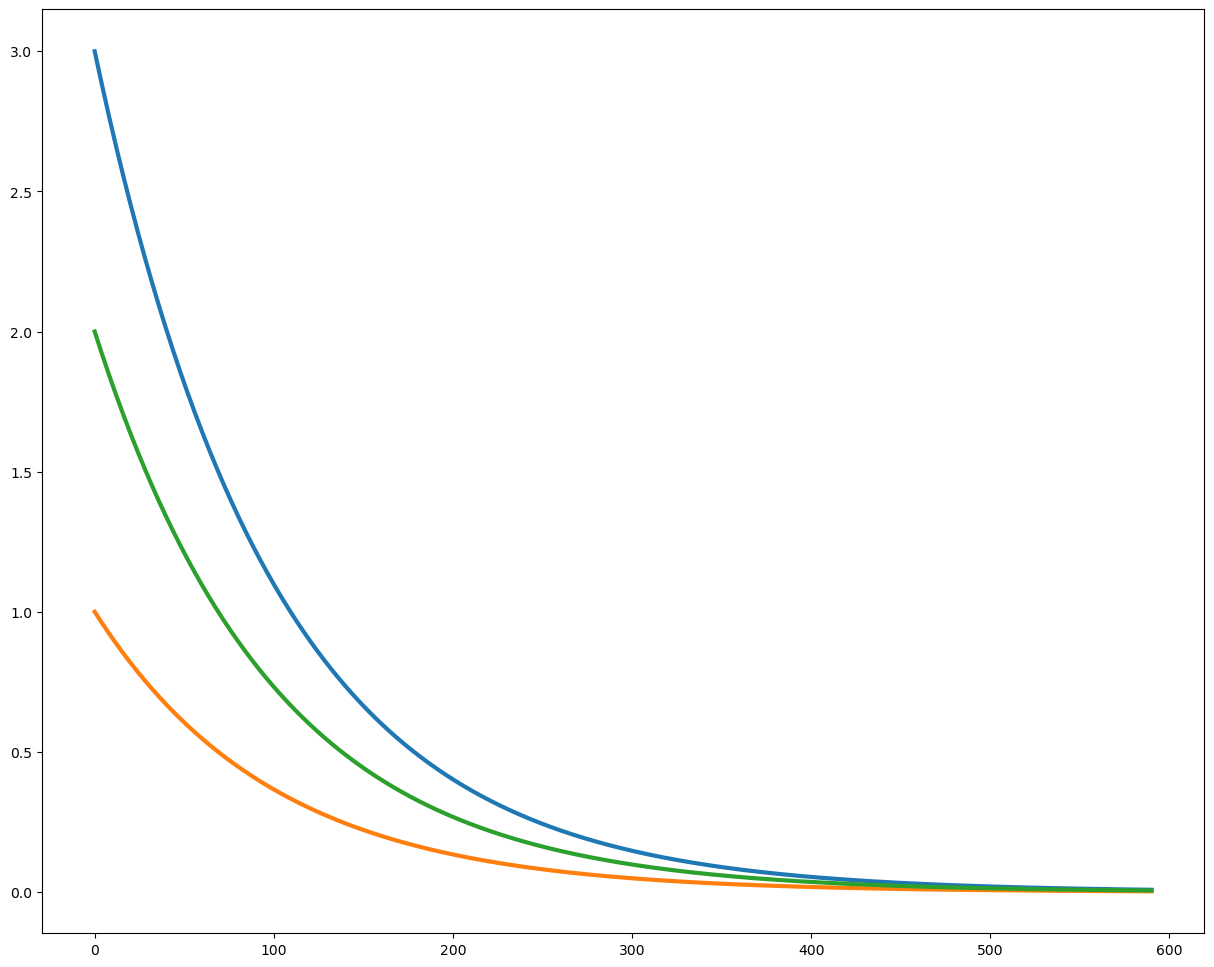

In [10]:
# Define linear system

x_att = np.array([0,0,0])
x_init = np.array([3, 1, 2])
A = -1 * np.eye(3)
compute_xdot = lambda x: (A @ (x-x_att).reshape(-1, 1))[:, 0]

x_list = [x_init]
x_dot_list = []
while np.linalg.norm(x_list[-1] - x_att) > 0.01:
    x_curr = x_list[-1]
    x_dot = compute_xdot(x_curr)
    x_dot_list.append(x_dot)
    x_new = x_curr + x_dot * 0.01
    x_list.append(x_new)

x_list = np.array(x_list)
fig, ax = plt.subplots(figsize=(15, 12))
ax.plot(x_list, linewidth=3, alpha=1)


In [11]:
def modulation_param(x_ori, x_mod):
    mu = np.cross(x_ori, x_mod) / (np.linalg.norm(x_ori) * np.linalg.norm(x_mod)) # rotation vector
    phi = np.arccos(np.clip(np.dot(x_ori, x_mod) / (np.linalg.norm(x_ori) * np.linalg.norm(x_mod)), -1.0, 1.0)) # rotation angle
    kappa = np.linalg.norm(x_mod) / np.linalg.norm(x_ori) - 1.0
    return mu, phi, kappa

def modulation_matrix(mu_phi, kappa):
    M = (1+kappa) * R.from_rotvec(mu_phi).as_matrix() 
    return M

idx = 150 

x_rollout = x_list

x_in_m = x_rollout[idx]

x_dot = compute_xdot(x_in_m)

print("Original velocity: ", x_dot)

x_dot_m = x_dot / 2.0

print("Modulaated velocity: ", x_dot_m)

mu, phi, kappa = modulation_param(x_dot, x_dot_m)

M = modulation_matrix(mu*phi, kappa)

print(M)

X = x_in_m.reshape(1, -1)
y = np.hstack((kappa, phi * mu[0], phi * mu[1], phi * mu[2])).reshape(1, -1)

print(y)

Original velocity:  [-0.66435536 -0.22145179 -0.44290357]
Modulaated velocity:  [-0.33217768 -0.11072589 -0.22145179]
[[0.5 0.  0. ]
 [0.  0.5 0. ]
 [0.  0.  0.5]]
[[-0.5  0.   0.   0. ]]


In [12]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as CK, WhiteKernel as WK

# Hyperparameters matching your C++ names
sigma_f = 10     # signal std
l_scale = 0.01     # length scale
sigma_n = 0.00001    # noise std

kernel = CK(sigma_f**2, (1e-6, 1e6)) * RBF(length_scale=l_scale, length_scale_bounds=(1e-6, 1e6)) \
         + WK(noise_level=sigma_n**2, noise_level_bounds=(1e-12, 1e3))

gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0, normalize_y=False, n_restarts_optimizer=3)
gpr.fit(X, y)

X_test = X
y_mean, y_std = gpr.predict(X_test, return_std=True)

M = modulation_matrix(y_mean[0, 1:4], y_mean[0, 0])

print(M)

[[0.5 0.  0. ]
 [0.  0.5 0. ]
 [0.  0.  0.5]]


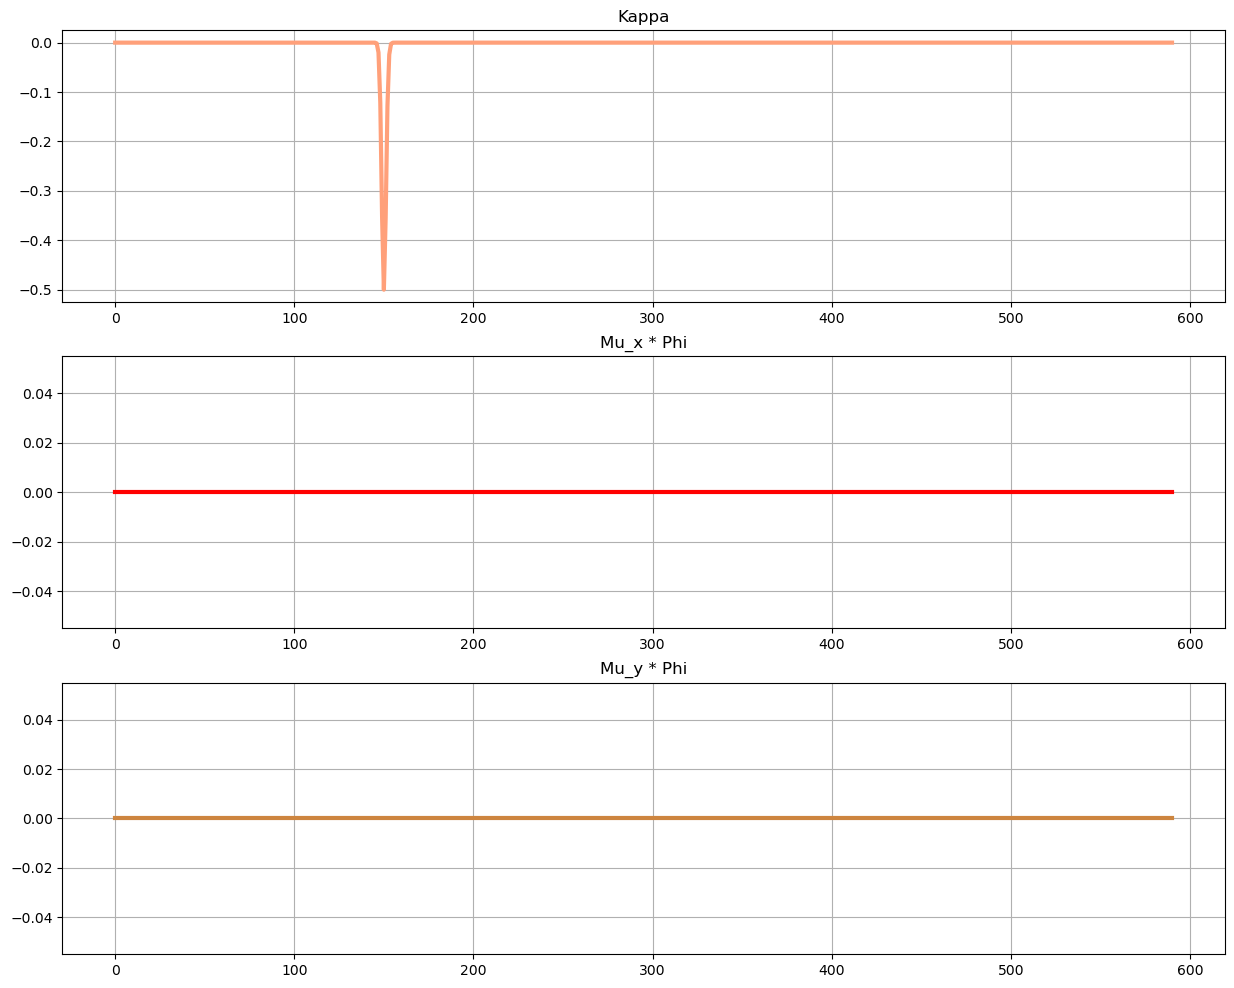

In [13]:
y_mean, y_std = gpr.predict(x_rollout, return_std=True)

fig, axs = plt.subplots(3, 1, figsize=(15, 12))
colors = ['lightsalmon', 'red', 'peru']
titles = ['Kappa', 'Mu_x * Phi', 'Mu_y * Phi', 'Mu_z * Phi']

for k in range(3):
    axs[k].plot(y_mean[:, k], linewidth=3, color=colors[k], alpha=1)
    axs[k].set_title(titles[k])
    axs[k].grid(True)

# plt.tight_layout()

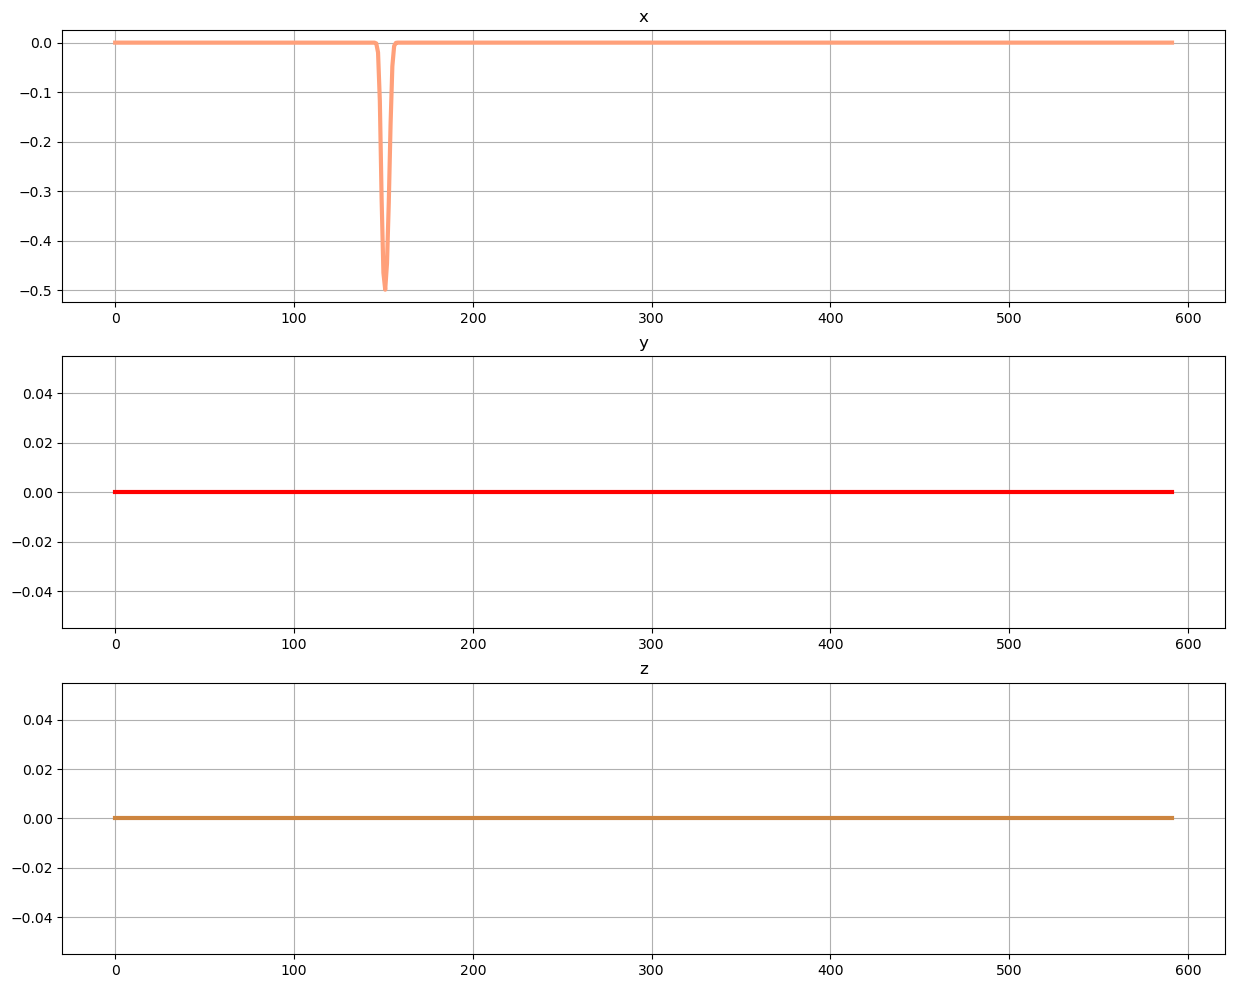

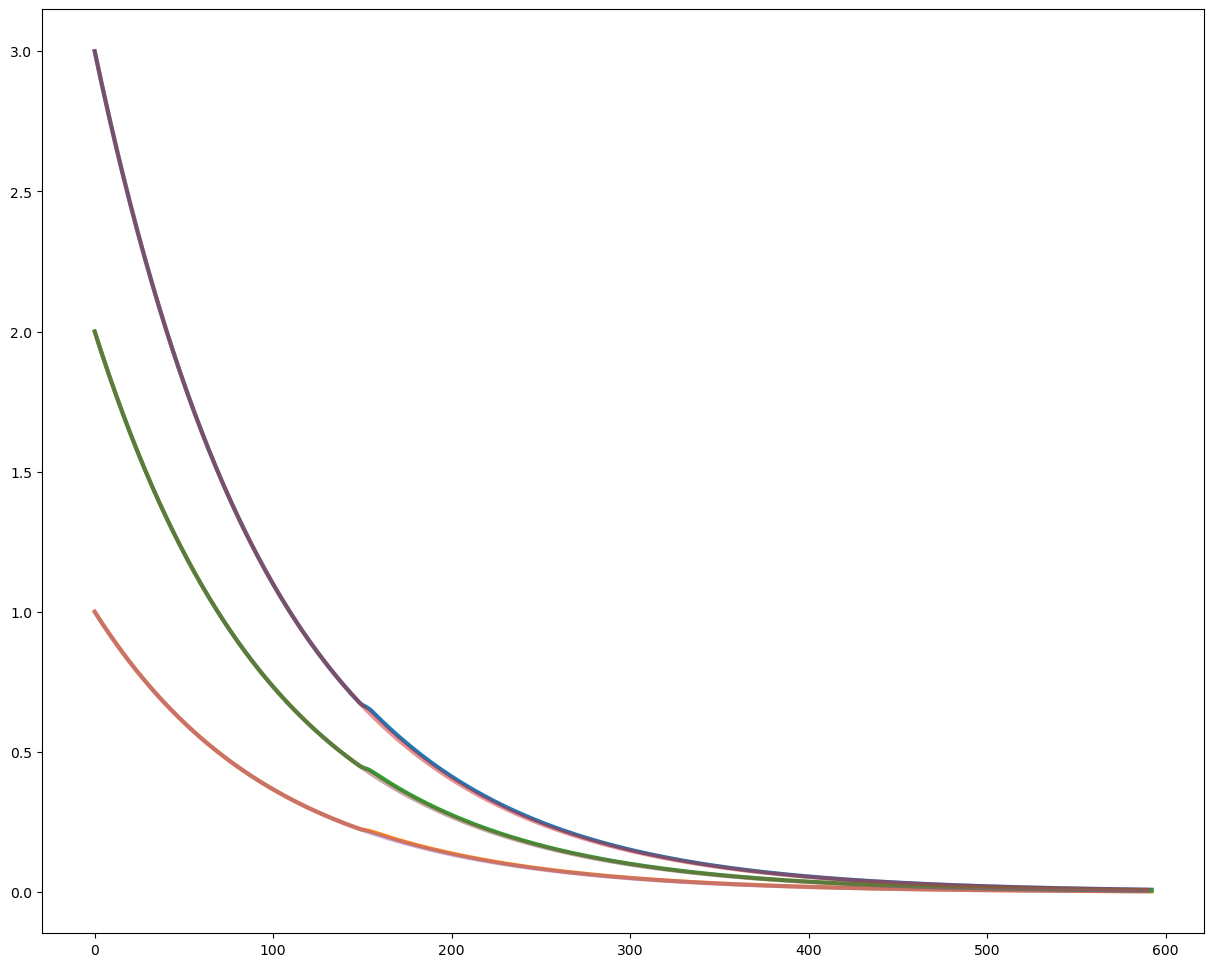

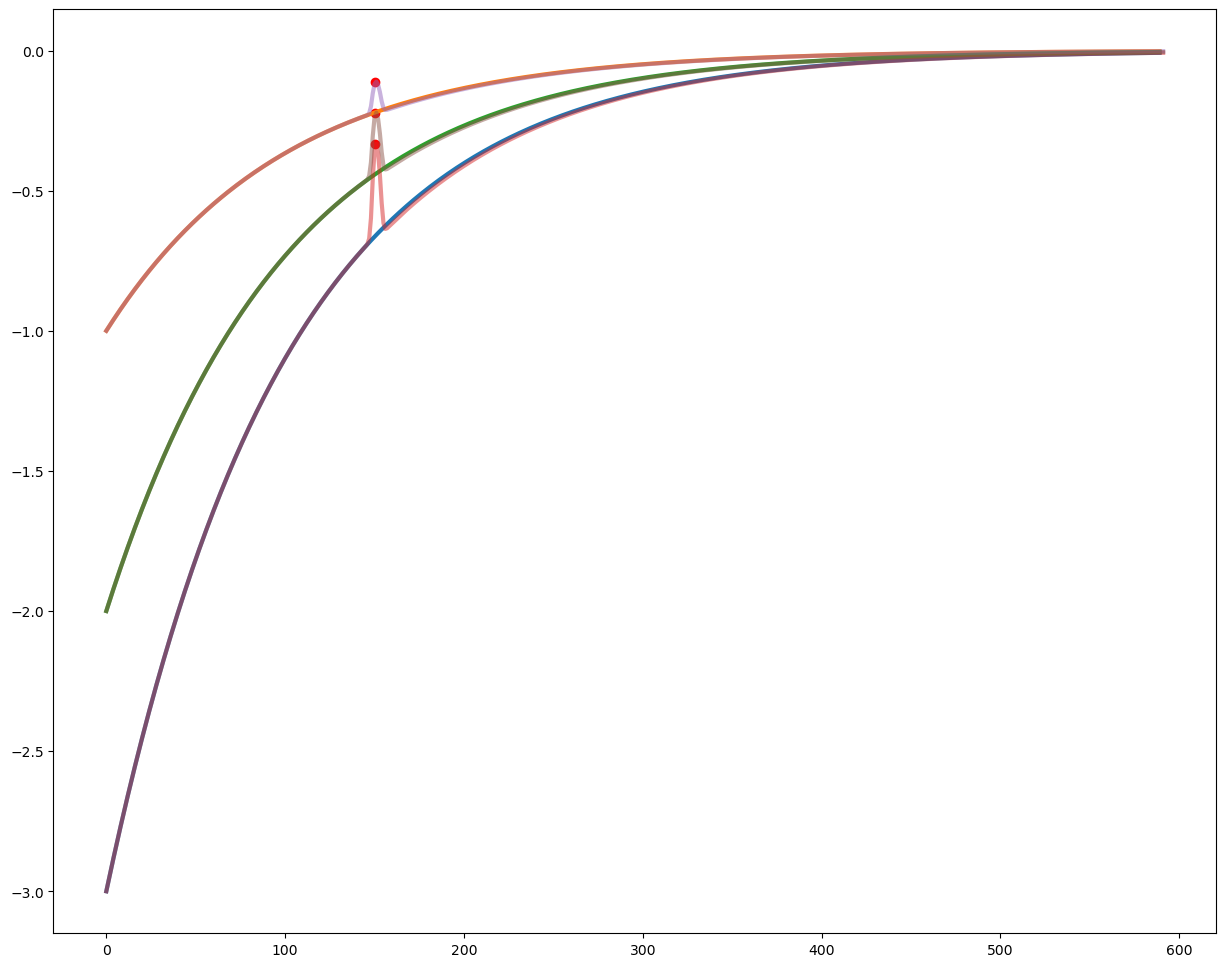

In [14]:
x_rollout_m = [x_init]

y_mean_list = []
x_dot_list_2 = []
while np.linalg.norm(x_rollout_m[-1] - x_att) > 0.01:
    x_curr = x_rollout_m[-1]

    y_mean, y_std = gpr.predict(x_curr.reshape(1,-1), return_std=True)
    y_mean_list.append(y_mean[0, :])
    M = modulation_matrix(y_mean[0, 1:4], y_mean[0, 0])

    # x_new = x_curr + compute_xdot(x_curr) * 0.01

    x_dot = (M @ compute_xdot(x_curr).reshape(-1, 1))[:, 0]

    x_dot_list_2.append(x_dot)

    x_new = x_curr +  x_dot * 0.01

    x_rollout_m.append(x_new)


fig, axs = plt.subplots(3, 1, figsize=(15, 12))
colors = ['lightsalmon', 'red', 'peru']
titles = ['x', 'y', 'z']

y_mean_arr = np.array(y_mean_list)

for k in range(3):
    axs[k].plot(y_mean_arr[:, k], linewidth=3, color=colors[k], alpha=1)
    axs[k].set_title(titles[k])
    axs[k].grid(True)


x_rollout_m = np.array(x_rollout_m)
fig, ax = plt.subplots(figsize=(15, 12))
ax.plot(x_rollout_m, linewidth=3, alpha=1)
ax.plot(x_rollout, linewidth=3, alpha=0.5)



x_dot_list = np.array(x_dot_list)
x_dot_list_2 = np.array(x_dot_list_2)
fig, ax = plt.subplots(figsize=(15, 12))
ax.plot(x_dot_list, linewidth=3, alpha=1)
ax.plot(x_dot_list_2, linewidth=3, alpha=0.5)
ax.scatter(idx * np.ones((3,)), x_dot_m, color='red')

